# Notebook 14 — Zero-Label Pipeline: Detección por Persona
## VisionOps Equipo #56 | YOLOv8 + ByteTrack + V-JEPA2 + IsolationForest + Mahalanobis

### Integra lo mejor de NB12 y NB13

| Característica | NB12 | NB13 | **NB14** |
|---|---|---|---|
| ByteTrack por persona | ✅ | ❌ | ✅ |
| Crop con padding contextual | ✅ | ❌ | ✅ |
| V-JEPA2 por persona (no escena) | ✅ | ❌ | ✅ |
| InactivityDetector por track | ❌ | escena | ✅ **por track** |
| IsoForest + Mahalanobis por track | ❌ | escena | ✅ **por track** |
| Warm-up calibrado por track | ❌ | ✅ | ✅ |
| Fusion layer | ❌ | ✅ | ✅ |
| Métricas P/R/F1 | ❌ | ✅ | ✅ |
| Video anotado de salida | ✅ | ❌ | ✅ |
| Agregación escena desde personas | ❌ | ❌ | ✅ **nuevo** |

### Arquitectura
```
Video MP4
    ↓
YOLOv8n (personas, clase 0)
    ↓
ByteTrack → track_id persistente por persona
    ↓  crop 224×224 con padding contextual
Buffer de 16 frames por track_id
    ↓
V-JEPA2 frozen → embedding 1024-d por persona
    ↓
 ┌─────────────────────────────────────┐
 │  Por track_id (sin etiquetas)       │
 │  Head A: InactivityDetector         │
 │    - EWMA centroide bbox            │
 │    - Varianza temporal del embedding│
 │    - Tiempo sin moverse (dwell)     │
 │  Head B: ShiftAnomalyDetector       │
 │    - Warm-up N clips por track      │
 │    - IsolationForest + PCA          │
 │    - Mahalanobis al centroide       │
 └──────────────┬──────────────────────┘
                ↓
 Fusion por track → alert_score [0,1]
                ↓
 Agregación escena:
   inact_scene  = media ponderada por dwell_time
   anomaly_scene= máximo de anomaly scores
                ↓
 Métricas P/R/F1 vs ground truth
 + Video anotado de salida
```

## 0. Instalación de dependencias

In [1]:
import importlib, subprocess, sys

def pip_install(*pkgs):
    for pkg in pkgs:
        mod = pkg.split('[')[0].replace('-','_')
        if importlib.util.find_spec(mod) is None:
            print(f'Instalando {pkg}...')
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
        else:
            print(f'✓ {pkg}')

pip_install(
    'opencv-python-headless',
    'ultralytics',
    'scikit-learn',
    'numpy',
    'matplotlib',
    'pandas',
    'tqdm',
)
# Opcional — V-JEPA2 real (~3 GB):
# pip_install('torch', 'transformers', 'huggingface_hub')
print('\n✅ Dependencias listas')

Instalando opencv-python-headless...



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


✓ ultralytics
Instalando scikit-learn...
✓ numpy
✓ matplotlib
✓ pandas
✓ tqdm

✅ Dependencias listas



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import json, time, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm

# ── V-JEPA2 ───────────────────────────────────────────────────────────────────
VJEPA_AVAILABLE = False
DEVICE = 'cpu'
try:
    import torch
    from transformers import AutoModel, AutoVideoProcessor
    VJEPA_AVAILABLE = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'🟢 V-JEPA2 disponible — device: {DEVICE}')
except ImportError:
    print('🟡 V-JEPA2 no instalado — usando fallback (flujo óptico por crop)')

# ── YOLOv8 ────────────────────────────────────────────────────────────────────
YOLO_AVAILABLE = False
try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
    print('🟢 YOLOv8 disponible')
except ImportError:
    print('🔴 YOLOv8 no instalado — instalar ultralytics')

# Colores por track_id para visualización
TRACK_PALETTE = [
    (0,200,100),(50,150,220),(220,150,50),(180,50,220),
    (50,200,200),(220,80,80),(100,220,50),(220,50,150),
    (50,100,220),(200,200,50),(150,50,200),(50,220,150),
]

def track_color(track_id: int) -> tuple:
    return TRACK_PALETTE[track_id % len(TRACK_PALETTE)]

print('\n✅ Imports completos')

🟢 V-JEPA2 disponible — device: cpu
🟢 YOLOv8 disponible

✅ Imports completos


In [3]:
# ═══════════════════════════════════════════════════════════════════
#  VIDEO
# ═══════════════════════════════════════════════════════════════════

# Ruta al video MP4. None = genera video sintético de prueba
VIDEO_PATH = None          # ← None para que no use un video directo
USE_INHARD_SEQUENCE = True # ← activa la construcción desde InHARD

INHARD_ROOT = Path("/Users/landyschlebach/Dataset In Hard/01-InHARD.7z/Segmented/RGBSegmented")

# ── Tracking ──────────────────────────────────────────────────────
SAMPLE_EVERY_N   = 3       # procesar 1 de cada N frames
YOLO_CONFIDENCE  = 0.40    # confianza mínima de detección
BBOX_PADDING     = 0.25    # padding contextual alrededor del bbox
CROP_SIZE        = 224     # tamaño del crop por persona
BUFFER_SIZE      = 16      # frames por ventana de inferencia V-JEPA

# ── Warm-up ───────────────────────────────────────────────────────
# Número de embeddings por track antes de calibrar el detector.
# En producción equivale a los primeros ~10 min del turno.
WARMUP_EMBEDDINGS_PER_TRACK = 3   # reduce a 3 para videos cortos

# ── Fusion layer ──────────────────────────────────────────────────
W_INACTIVITY = 0.45
W_ANOMALY    = 0.45
W_HAR        = 0.10   # sin checkpoints HAR activos

# ── Salida ────────────────────────────────────────────────────────
SAVE_ANNOTATED_VIDEO = True
OUTPUTS = Path('outputs/14_zerolabel_perperson')
OUTPUTS.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
#  GROUND TRUTH MANUAL
#  Intervalos [inicio_seg, fin_seg] con eventos reales en el video.
#  Puede quedar vacío si no tienes etiquetas — las métricas se omiten.
# ═══════════════════════════════════════════════════════════════════

GT_INACTIVITY_INTERVALS = [[5,12]
    # [30, 50],   # ejemplo: segundo 30–50 hay inactividad
]

GT_ANOMALY_INTERVALS = [
    # [90, 110],  # ejemplo: segundo 90–110 hay anomalía
]

# ═══════════════════════════════════════════════════════════════════
print('Configuración:')
print(f'  Video:              {VIDEO_PATH or "[sintético]"}')
print(f'  Sample every N:     {SAMPLE_EVERY_N}')
print(f'  Buffer por track:   {BUFFER_SIZE} frames')
print(f'  Warm-up por track:  {WARMUP_EMBEDDINGS_PER_TRACK} embeddings')
print(f'  GT inactividad:     {len(GT_INACTIVITY_INTERVALS)} intervalos')
print(f'  GT anomalía:        {len(GT_ANOMALY_INTERVALS)} intervalos')

Configuración:
  Video:              [sintético]
  Sample every N:     3
  Buffer por track:   16 frames
  Warm-up por track:  3 embeddings
  GT inactividad:     1 intervalos
  GT anomalía:        0 intervalos


Generando video sintético (180s, 2 personas)...


Generando video sintético:   0%|          | 0/2700 [00:00<?, ?it/s]

✅ outputs/14_zerolabel_perperson/synthetic_test.mp4
   GT inactividad: [[5, 12]]
   GT anomalía:    [[120, 150]]


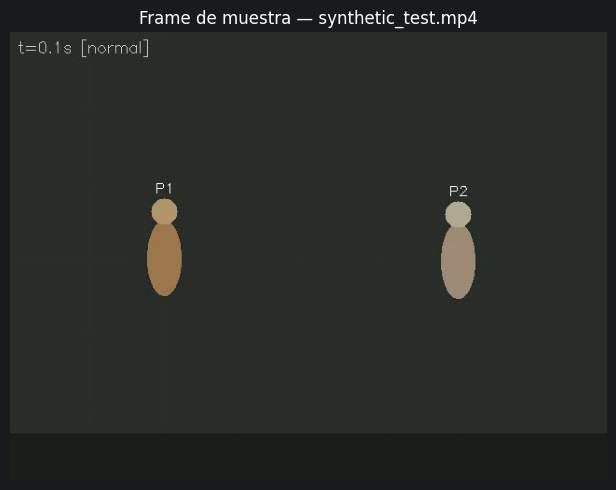


Video: 640×480  15fps  2700 frames  180s


In [4]:
def generate_synthetic_video(path: str, fps: int = 15,
                              duration_sec: int = 180) -> dict:
    """
    Genera video sintético con N personas simuladas:
      0–60s  : 2 personas activas
      60–90s : inactividad (personas quietas)
      90–120s: actividad normal
      120–150s: anomalía (objeto extraño + flash)
      150–180s: actividad normal
    """
    W, H = 640, 480
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(path, fourcc, fps, (W, H))
    total = fps * duration_sec
    np.random.seed(42)

    N_PERSONS = 2
    px = np.array([160.0, 480.0])
    py = np.array([240.0, 240.0])
    vx = np.array([ 35.0, -30.0])
    vy = np.array([ 18.0,  22.0])

    phases = [(0,60,'normal'),(60,90,'inactivity'),
              (90,120,'normal'),(120,150,'anomaly'),(150,180,'normal')]

    for fi in tqdm(range(total), desc='Generando video sintético'):
        t = fi / fps
        phase = next(p[2] for p in phases if p[0]<=t<p[1]+0.01)

        bg = np.full((H,W,3), 45, np.uint8)
        # Grid de fábrica
        for gx in range(0,W,80): cv2.line(bg,(gx,0),(gx,H),(50,50,50),1)
        for gy in range(0,H,80): cv2.line(bg,(0,gy),(W,gy),(50,50,50),1)
        cv2.rectangle(bg,(0,H-50),(W,H),(30,30,30),-1)  # suelo

        move = phase != 'inactivity'
        for i in range(N_PERSONS):
            if move:
                px[i] += vx[i]/fps + np.random.randn()*2
                py[i] += vy[i]/fps + np.random.randn()*1
                if px[i]<40 or px[i]>W-40: vx[i]*=-1
                if py[i]<40 or py[i]>H-70: vy[i]*=-1
            color = (80+i*40, 120+i*20, 160) if move else (60,60,80)
            # cuerpo
            cv2.ellipse(bg,(int(px[i]),int(py[i])),(18,40),0,0,360,color,-1)
            # cabeza
            cv2.circle(bg,(int(px[i]),int(py[i])-50),14,(color[0]+30,color[1]+30,color[2]+20),-1)
            # ID
            cv2.putText(bg,f'P{i+1}',(int(px[i])-10,int(py[i])-70),
                       cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)

        if phase == 'anomaly':
            v = int(50+80*abs(np.sin(t*3)))
            bg[:H//2,:] = np.clip(bg[:H//2,:].astype(int)+v,0,255).astype(np.uint8)
            cv2.rectangle(bg,(W//2-40,H//2-30),(W//2+40,H//2+30),(0,0,200),-1)
            cv2.putText(bg,'OBJETO',(W//2-30,H//2+5),
                       cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)

        cv2.putText(bg,f't={t:.1f}s [{phase}]',(8,22),
                   cv2.FONT_HERSHEY_SIMPLEX,0.55,(200,200,200),1)
        out.write(bg)

    out.release()
    return {
        'gt_inactivity': [[60,90]],
        'gt_anomaly':    [[120,150]],
        'fps': fps, 'duration_sec': duration_sec,
    }


# ── Cargar o generar ──────────────────────────────────────────────────────────
if VIDEO_PATH is None:
    _syn = str(OUTPUTS / 'synthetic_test.mp4')
    print('Generando video sintético (180s, 2 personas)...')
    _meta = generate_synthetic_video(_syn, fps=15, duration_sec=180)
    VIDEO_PATH = _syn
    if not GT_INACTIVITY_INTERVALS: GT_INACTIVITY_INTERVALS = _meta['gt_inactivity']
    if not GT_ANOMALY_INTERVALS:    GT_ANOMALY_INTERVALS    = _meta['gt_anomaly']
    print(f'✅ {_syn}')
    print(f'   GT inactividad: {GT_INACTIVITY_INTERVALS}')
    print(f'   GT anomalía:    {GT_ANOMALY_INTERVALS}')
else:
    print(f'✅ Usando: {VIDEO_PATH}')

cap = cv2.VideoCapture(VIDEO_PATH)
VIDEO_FPS    = cap.get(cv2.CAP_PROP_FPS) or 15.0
VIDEO_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VIDEO_W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VIDEO_H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
VIDEO_DUR    = VIDEO_FRAMES / VIDEO_FPS

# Mostrar frame de muestra
cap.read()  # skip frame 0
ret, sample = cap.read()
cap.release()
if ret:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame de muestra — {Path(VIDEO_PATH).name}')
    ax.axis('off'); plt.tight_layout(); plt.show()

print(f'\nVideo: {VIDEO_W}×{VIDEO_H}  {VIDEO_FPS:.0f}fps  '
      f'{VIDEO_FRAMES} frames  {VIDEO_DUR:.0f}s')

In [5]:
# ── Construcción de secuencia de prueba desde InHARD ─────────────────────
if USE_INHARD_SEQUENCE:
    import random
    out_path = OUTPUTS / "inhard_test_sequence.mp4"

    # Clases normales (2 minutos) + inactividad (30s) + vuelta a normal (30s)
    normal_dir = INHARD_ROOT / "Assemble system"
    idle_dir   = INHARD_ROOT / "No action"

    normal_clips = sorted(normal_dir.glob("*.mp4"))[:24]  # ~2 min
    idle_clips   = sorted(idle_dir.glob("*.mp4"))[:6]     # ~30s
    extra_clips  = sorted(normal_dir.glob("*.mp4"))[24:30] # ~30s

    sequence = list(normal_clips) + list(idle_clips) + list(extra_clips)

    # Calcular timestamps GT de inactividad
    gt_idle_intervals = []
    t = 0.0
    writer = None
    W, H = 640, 480
    FPS_OUT = 15

    print("Construyendo secuencia de prueba...")
    for clip_path in sequence:
        cap = cv2.VideoCapture(str(clip_path))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25
        n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Marcar inicio de inactividad
        if clip_path in list(idle_clips):
            if not gt_idle_intervals or gt_idle_intervals[-1][1] is not None:
                gt_idle_intervals.append([t, None])
        elif gt_idle_intervals and gt_idle_intervals[-1][1] is None:
            gt_idle_intervals[-1][1] = t

        if writer is None:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(str(out_path), fourcc, FPS_OUT, (W, H))

        while True:
            ret, frame = cap.read()
            if not ret: break
            writer.write(cv2.resize(frame, (W, H)))

        t += n / fps
        cap.release()

    # Cerrar último intervalo si quedó abierto
    if gt_idle_intervals and gt_idle_intervals[-1][1] is None:
        gt_idle_intervals[-1][1] = t

    if writer:
        writer.release()

    # Sobreescribir VIDEO_PATH y GT
    VIDEO_PATH = str(out_path)
    GT_INACTIVITY = [(s, e) for s, e in gt_idle_intervals]
    GT_ANOMALY    = []

    print(f"Secuencia construida: {out_path}")
    print(f"Duración total:       {t:.1f}s")
    print(f"GT inactividad:       {[(round(s,1), round(e,1)) for s,e in GT_INACTIVITY]}")

Construyendo secuencia de prueba...
Secuencia construida: outputs/14_zerolabel_perperson/inhard_test_sequence.mp4
Duración total:       127.7s
GT inactividad:       [(81.9, 108.9)]


In [6]:
class EmbeddingExtractor:
    """
    Extrae embedding de un clip de crops de UNA persona.
    Modo real:    V-JEPA2-ViT-L → 1024-d L2-normalizado
    Modo fallback: histograma de flujo óptico por crop → 29-d normalizado
    """
    VJEPA_ID = 'facebook/vjepa2-vitl-fpc16-256-ssv2'

    def __init__(self):
        self._model = None
        self._proc  = None
        self.backend = 'motion_fallback'
        self.emb_dim = 29
        if VJEPA_AVAILABLE:
            self._load()

    def _load(self):
        try:
            print(f'Cargando {self.VJEPA_ID} (puede tardar ~2 min)...')
            self._proc  = AutoVideoProcessor.from_pretrained(self.VJEPA_ID)
            self._model = AutoModel.from_pretrained(
                self.VJEPA_ID, trust_remote_code=True).to(DEVICE).eval()
            self.backend = 'vjepa2_hf'
            self.emb_dim = 1024
            print(f'✅ V-JEPA2 en {DEVICE}')
        except Exception as e:
            print(f'⚠️  {e} — usando fallback')

    def extract(self, crops_bgr: list) -> Optional[np.ndarray]:
        """crops_bgr: lista de arrays (CROP_SIZE, CROP_SIZE, 3) BGR"""
        if len(crops_bgr) < 2:
            return None
        # Submuestrear a BUFFER_SIZE
        n = BUFFER_SIZE
        idx = np.linspace(0, len(crops_bgr)-1, min(n, len(crops_bgr)), dtype=int)
        sel = [crops_bgr[i] for i in idx]
        if self.backend == 'vjepa2_hf' and self._model is not None:
            return self._vjepa(sel)
        return self._flow(sel)

    def _vjepa(self, frames: list) -> Optional[np.ndarray]:
        try:
            rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames]
            video = np.stack(rgb)  # (T,H,W,3)
            inp = self._proc(list(video), return_tensors='pt')
            inp = {k: v.to(DEVICE) for k,v in inp.items()}
            with torch.inference_mode():
                out = self._model(**inp)
                # ── Corrección NB13: separar spatial pool del temporal pool ──
                # last_hidden_state: (1, T*N, D)
                # → reshape (1, T, N, D) → mean spatial → (1, T, D) → mean temporal
                hidden = out.last_hidden_state  # (1, T*N, D)
                T = len(frames)
                N = hidden.shape[1] // T
                emb = hidden.reshape(1, T, N, -1).mean(2).mean(1).squeeze(0)
            e = emb.cpu().numpy().astype(np.float32)
            n = np.linalg.norm(e)
            return e / (n + 1e-8)
        except Exception as ex:
            print(f'V-JEPA fallo: {ex}')
            return self._flow(frames)

    def _flow(self, frames: list) -> np.ndarray:
        """Flujo óptico por crop — fallback sin pesos."""
        mags, angs = [], []
        prev = cv2.GaussianBlur(
            cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY), (5,5), 1.5
        ).astype(np.float32)
        for f in frames[1:]:
            curr = cv2.GaussianBlur(
                cv2.cvtColor(f, cv2.COLOR_BGR2GRAY), (5,5), 1.5
            ).astype(np.float32)
            flow = cv2.calcOpticalFlowFarneback(prev,curr,None,0.5,3,15,3,5,1.2,0)
            mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
            mags.append(float(mag.mean()))
            angs.append(float(ang.mean()))
            prev = curr
        hm,_ = np.histogram(mags, bins=16, range=(0,20))
        ha,_ = np.histogram(angs, bins=8, range=(0,2*np.pi))
        vec = np.concatenate([
            hm.astype(np.float32), ha.astype(np.float32),
            [np.mean(mags), np.std(mags), np.max(mags),
             np.mean(angs), np.std(angs)]
        ])
        n = np.linalg.norm(vec)+1e-8
        return (vec/n).astype(np.float32)


print('EmbeddingExtractor definido ✓')

EmbeddingExtractor definido ✓


In [7]:
class TrackInactivityDetector:
    """
    Detector de inactividad POR PERSONA (track_id).
    Combina tres señales, todas sin etiquetas:
      1. EWMA de desplazamiento del centroide del bbox
      2. Varianza temporal del embedding V-JEPA del crop
      3. Tiempo sin desplazamiento significativo (dwell_time)
    Se calibra automáticamente con los primeros WARMUP_EMBEDDINGS embeddings.
    """
    def __init__(self, track_id: int, ewma_alpha: float = 0.08):
        self.track_id = track_id
        self._alpha   = ewma_alpha
        # Centroide bbox
        self._cx_prev: Optional[float] = None
        self._cy_prev: Optional[float] = None
        self._disp_ewma: float = 0.0
        self._disp_buf: deque = deque(maxlen=200)
        # Embedding variance
        self._emb_buf:  deque = deque(maxlen=20)   # últimos embeddings
        self._emb_var_buf: deque = deque(maxlen=30)
        # Calibración
        self._disp_mu: Optional[float] = None
        self._disp_sigma: Optional[float] = None
        self._var_mu: Optional[float] = None
        self.calibrated = False
        self._warmup_disps: list = []
        self._warmup_vars:  list = []

    # ── Actualización frame a frame ───────────────────────────────
    def update_bbox(self, cx_norm: float, cy_norm: float) -> float:
        """cx/cy normalizados [0,1] respecto al frame."""
        if self._cx_prev is None:
            self._cx_prev, self._cy_prev = cx_norm, cy_norm
            return 0.0
        disp = ((cx_norm - self._cx_prev)**2 +
                (cy_norm - self._cy_prev)**2) ** 0.5
        self._cx_prev, self._cy_prev = cx_norm, cy_norm
        self._disp_ewma = self._alpha * disp + (1-self._alpha) * self._disp_ewma
        self._disp_buf.append(self._disp_ewma)
        return self._disp_ewma

    def update_embedding(self, emb: np.ndarray) -> float:
        self._emb_buf.append(emb)
        if len(self._emb_buf) >= 2:
            stack = np.stack(list(self._emb_buf))
            var = float(stack.std(axis=0).mean())
        else:
            var = 0.0
        self._emb_var_buf.append(var)
        return var

    # ── Warm-up ───────────────────────────────────────────────────
    def add_warmup(self, disp: float, emb_var: float):
        self._warmup_disps.append(disp)
        self._warmup_vars.append(emb_var)

    def calibrate(self):
        if self._warmup_disps:
            self._disp_mu    = float(np.mean(self._warmup_disps))
            self._disp_sigma = float(np.std(self._warmup_disps)) + 1e-6
        if self._warmup_vars:
            self._var_mu = float(np.mean(self._warmup_vars))
        self.calibrated = True

    # ── Score ──────────────────────────────────────────────────────
    def score(self) -> dict:
        if not self.calibrated:
            return {'inactivity_score': 0.0, 'severity': 'warming_up',
                    'components': {}}

        # 1. Displacement score
        if self._disp_mu is not None and self._disp_mu > 0:
            z = (self._disp_mu - self._disp_ewma) / (self._disp_sigma or 1e-6)
            disp_score = float(1 / (1 + np.exp(-z + 1.5)))
        else:
            disp_score = 0.0

        # 2. Embedding variance score (baja varianza = persona estática)
        if self._emb_var_buf and self._var_mu and self._var_mu > 0:
            var_now = float(np.mean(list(self._emb_var_buf)[-8:]))
            var_ratio = var_now / self._var_mu
            var_score = float(np.clip(1.0 - var_ratio, 0, 1))
        else:
            var_score = 0.0

        # 3. Dwell score (cuánto tiempo llevamos sin movernos)
        if len(self._disp_buf) > 10:
            recent = list(self._disp_buf)[-20:]
            mu_r   = float(np.mean(recent))
            dwell  = float(np.clip(
                1.0 - mu_r / (self._disp_mu or 1e-6), 0, 1))
        else:
            dwell = 0.0

        inact = 0.45*disp_score + 0.30*var_score + 0.25*dwell
        sev   = ('critical' if inact>=0.72 else
                 'warning'  if inact>=0.48 else 'normal')
        return {
            'inactivity_score': round(float(inact), 4),
            'severity': sev,
            'components': {
                'displacement': round(disp_score, 4),
                'emb_variance': round(var_score, 4),
                'dwell':        round(dwell, 4),
            }
        }


print('TrackInactivityDetector definido ✓')

TrackInactivityDetector definido ✓


In [8]:
class TrackAnomalyDetector:
    """
    Detector de anomalías POR PERSONA (track_id).
    - Warm-up: acumula primeros N embeddings del crop de esa persona.
    - Fit: IsolationForest + PCA + Mahalanobis sobre su propio baseline.
    - Score: ensemble 0.6*Mahal + 0.4*IsoForest, normalizado z-score.
    """
    PCA_DIMS      = 16
    ISO_N         = 100
    CONTAMINATION = 0.05

    def __init__(self, track_id: int,
                 warmup_n: int = WARMUP_EMBEDDINGS_PER_TRACK):
        self.track_id  = track_id
        self._warmup_n = warmup_n
        self._pool:    list = []
        self._pca:     Optional[PCA] = None
        self._iso:     Optional[IsolationForest] = None
        self._mu:      Optional[np.ndarray] = None
        self._inv_cov: Optional[np.ndarray] = None
        self._s_mu:    float = 0.0
        self._s_sig:   float = 1.0
        self.warmed_up = False

    def add_warmup(self, emb: np.ndarray):
        self._pool.append(emb.flatten().astype(np.float32))
        if len(self._pool) >= self._warmup_n:
            self._fit()

    def _fit(self):
        X = np.stack(self._pool)
        d = min(self.PCA_DIMS, X.shape[1], max(2, X.shape[0]-1))
        self._pca = PCA(n_components=d, random_state=42).fit(X)
        Xr = self._pca.transform(X)
        self._mu = Xr.mean(0)
        cov = np.cov(Xr.T) + np.eye(d)*1e-6
        self._inv_cov = np.linalg.inv(
            cov if cov.ndim==2 else np.array([[cov]]))
        self._iso = IsolationForest(
            n_estimators=self.ISO_N,
            contamination=self.CONTAMINATION,
            random_state=42, n_jobs=-1).fit(Xr)
        raw = [self._raw(e) for e in self._pool]
        self._s_mu  = float(np.mean(raw))
        self._s_sig = float(np.std(raw)) + 1e-6
        self.warmed_up = True

    def score(self, emb: np.ndarray) -> dict:
        if not self.warmed_up:
            return {'anomaly_score': 0.0, 'severity': 'warming_up',
                    'warmed_up': False}
        raw = self._raw(emb.flatten())
        z   = (raw - self._s_mu) / self._s_sig
        s01 = float(np.clip(1/(1+np.exp(-z+2.0)), 0, 1))
        sev = ('critical' if s01>=0.75 else
               'warning'  if s01>=0.50 else 'normal')
        return {'anomaly_score': round(s01,4), 'severity': sev,
                'raw_score': round(float(raw),4), 'warmed_up': True}

    def _raw(self, flat: np.ndarray) -> float:
        xr   = self._pca.transform(flat.reshape(1,-1))[0]
        diff = xr - self._mu
        inv  = self._inv_cov
        mahal = float((diff @ inv @ diff)**0.5)
        iso   = float(-self._iso.score_samples(xr.reshape(1,-1))[0])
        return 0.6*mahal + 0.4*iso


print('TrackAnomalyDetector definido ✓')

TrackAnomalyDetector definido ✓


In [9]:
def track_fusion(inact_score: float, anom_score: float,
                 har_conf: float = 0.5) -> float:
    """Alert score por track_id."""
    return (W_INACTIVITY * inact_score
          + W_ANOMALY    * anom_score
          + W_HAR        * (1 - har_conf))


def scene_aggregation(track_scores: dict) -> dict:
    """
    Agrega los scores de todas las personas presentes en el frame.
    - inactivity_scene : media ponderada por n_frames de cada track
      (alguien inactivo más tiempo tiene más peso)
    - anomaly_scene    : máximo de anomaly scores
      (basta una persona anómala para alertar)
    - alert_scene      : fusion de ambos
    """
    if not track_scores:
        return {'inactivity_scene': 0.0, 'anomaly_scene': 0.0,
                'alert_scene': 0.0, 'n_persons': 0}

    inact_vals   = [v['inactivity_score'] for v in track_scores.values()]
    anom_vals    = [v['anomaly_score']    for v in track_scores.values()]
    dwell_w      = [max(v.get('n_frames', 1), 1) for v in track_scores.values()]
    total_w      = sum(dwell_w)

    inact_scene  = sum(i*w for i,w in zip(inact_vals, dwell_w)) / total_w
    anom_scene   = float(max(anom_vals))
    alert_scene  = track_fusion(inact_scene, anom_scene)

    return {
        'inactivity_scene': round(float(inact_scene), 4),
        'anomaly_scene':    round(anom_scene, 4),
        'alert_scene':      round(float(alert_scene), 4),
        'n_persons':        len(track_scores),
    }


print('Fusion + agregación de escena definidos ✓')

Fusion + agregación de escena definidos ✓


In [10]:
# ── Inicializar ───────────────────────────────────────────────────────────────
print('Inicializando pipeline...')
extractor = EmbeddingExtractor()
print(f'Backend: {extractor.backend}  (dim={extractor.emb_dim})')

if not YOLO_AVAILABLE:
    raise RuntimeError('YOLOv8 es requerido. Instalar: pip install ultralytics')

yolo = YOLO('yolov8n.pt')
print('YOLOv8n listo ✓')

# Registros por track_id
track_crops:    dict = defaultdict(lambda: deque(maxlen=BUFFER_SIZE*3))
track_inact:    dict = {}   # TrackInactivityDetector por track
track_anom:     dict = {}   # TrackAnomalyDetector por track
track_nframes:  dict = defaultdict(int)
track_warmup_done: set = set()
track_emb_count: dict = defaultdict(int)  # nro embeddings generados por track

# Resultados frame a frame
frame_records   = []   # un registro por frame procesado
scene_records   = []   # agregación de escena por frame
annotated_frames = []  # frames BGR anotados (para video de salida)

print('\n✅ Todo listo — comenzando procesamiento...')

Inicializando pipeline...
Cargando facebook/vjepa2-vitl-fpc16-256-ssv2 (puede tardar ~2 min)...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc16-256-ssv2
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.self_attn.q_proj.weight   | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc2.bias              | UNEXPECTED |  | 
pooler.cross_attention_layer.layer_norm1.bias                    | UNEXPECTED |  | 
pooler.cross_attention_layer.layer_norm2.weight                  | UNEXPECTED |  | 
pooler.cross_attention_layer.mlp.fc1.weight                      | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.layer_norm2.bias          | UNEXPECTED |  | 
pooler.cross_attention_layer.cross_attn.q_proj.weight            | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc2.weight            | UNEXPECTED |

✅ V-JEPA2 en cpu
Backend: vjepa2_hf  (dim=1024)
YOLOv8n listo ✓

✅ Todo listo — comenzando procesamiento...


In [ ]:
cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
t0_wall   = time.time()

pbar = tqdm(total=VIDEO_FRAMES // SAMPLE_EVERY_N, desc='Procesando')

while True:
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx % SAMPLE_EVERY_N != 0:
        frame_idx += 1
        continue

    t_sec  = frame_idx / VIDEO_FPS
    frame_small = cv2.resize(frame, (VIDEO_W, VIDEO_H))
    vis   = frame_small.copy()   # frame para anotación

    # ── 1. Detección + ByteTrack ──────────────────────────────────────────
    results = yolo.track(
        frame_small, classes=[0], conf=YOLO_CONFIDENCE,
        tracker='bytetrack.yaml', persist=True, verbose=False,
    )
    detections = []
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            if box.id is None: continue
            tid   = int(box.id.item())
            conf  = float(box.conf.item())
            x1,y1,x2,y2 = map(float, box.xyxy[0].cpu().numpy())
            detections.append({'tid': tid, 'conf': conf,
                               'x1':x1,'y1':y1,'x2':x2,'y2':y2})

            # ── Inicializar detectores para este track ────────────────
            if tid not in track_inact:
                track_inact[tid] = TrackInactivityDetector(tid)
            if tid not in track_anom:
                track_anom[tid]  = TrackAnomalyDetector(tid)

            # ── Crop con padding contextual ───────────────────────────
            pw = (x2-x1)*BBOX_PADDING; ph = (y2-y1)*BBOX_PADDING
            cx1 = max(0, int(x1-pw)); cy1 = max(0, int(y1-ph))
            cx2 = min(VIDEO_W, int(x2+pw))
            cy2 = min(VIDEO_H, int(y2+ph))
            if cx2>cx1 and cy2>cy1:
                crop = cv2.resize(frame_small[cy1:cy2,cx1:cx2],
                                  (CROP_SIZE, CROP_SIZE))
                track_crops[tid].append(crop)
                track_nframes[tid] += 1

            # ── Actualizar motion (centroide normalizado) ─────────────
            cx_n = ((x1+x2)/2) / VIDEO_W
            cy_n = ((y1+y2)/2) / VIDEO_H
            disp = track_inact[tid].update_bbox(cx_n, cy_n)

            # ── Extraer embedding cuando hay suficientes crops ─────────
            emb = None
            if len(track_crops[tid]) >= BUFFER_SIZE:
                emb = extractor.extract(list(track_crops[tid]))

            emb_var = 0.0
            if emb is not None:
                emb_var = track_inact[tid].update_embedding(emb)
                track_emb_count[tid] += 1

                # ── Warm-up o scoring ─────────────────────────────────
                if tid not in track_warmup_done:
                    track_inact[tid].add_warmup(disp, emb_var)
                    track_anom[tid].add_warmup(emb)
                    if track_anom[tid].warmed_up:
                        track_inact[tid].calibrate()
                        track_warmup_done.add(tid)

    # ── 2. Scores por track (solo tracks con warm-up listo) ───────────────
    track_scores_frame = {}
    for det in detections:
        tid = det['tid']
        if tid not in track_warmup_done:
            continue

        inact_out = track_inact[tid].score()

        # Para anomalía necesitamos el embedding actual
        emb_now = extractor.extract(list(track_crops[tid])) \
                  if len(track_crops[tid]) >= BUFFER_SIZE else None
        anom_out = track_anom[tid].score(emb_now) \
                   if emb_now is not None else \
                   {'anomaly_score': 0.0, 'severity': 'no_emb'}

        alert = track_fusion(
            inact_out['inactivity_score'],
            anom_out['anomaly_score'],
        )

        track_scores_frame[tid] = {
            'inactivity_score': inact_out['inactivity_score'],
            'inact_severity':   inact_out['severity'],
            'anomaly_score':    anom_out['anomaly_score'],
            'anom_severity':    anom_out['severity'],
            'alert_score':      round(alert, 4),
            'n_frames':         track_nframes[tid],
            **{f'comp_{k}': v
               for k,v in inact_out.get('components',{}).items()},
        }

        # Registro por persona
        frame_records.append({
            'frame_idx': frame_idx,
            't_sec':     round(t_sec, 3),
            'track_id':  tid,
            **track_scores_frame[tid],
        })

    # ── 3. Agregación de escena ───────────────────────────────────────────
    scene = scene_aggregation(track_scores_frame)
    scene_records.append({'frame_idx': frame_idx, 't_sec': round(t_sec,3),
                          **scene})

    # ── 4. Anotación del frame ────────────────────────────────────────────
    # Header de escena
    scene_col = (0,200,80)
    if scene['alert_scene'] >= 0.70:
        scene_col = (0,0,220)
    elif scene['alert_scene'] >= 0.45:
        scene_col = (0,140,220)
    cv2.rectangle(vis, (0,0), (VIDEO_W, 32), (20,20,20), -1)
    cv2.putText(vis,
        f't={t_sec:.1f}s  Personas:{scene["n_persons"]}  '
        f'Inact:{scene["inactivity_scene"]:.2f}  '
        f'Anom:{scene["anomaly_scene"]:.2f}  '
        f'Alert:{scene["alert_scene"]:.2f}',
        (6,22), cv2.FONT_HERSHEY_SIMPLEX, 0.48, scene_col, 1)

    for det in detections:
        tid = det['tid']
        x1,y1,x2,y2 = int(det['x1']),int(det['y1']),int(det['x2']),int(det['y2'])
        color = track_color(tid)
        sc    = track_scores_frame.get(tid, {})
        alert = sc.get('alert_score', None)

        # Box — color por estado
        if alert is not None:
            if alert >= 0.70:   box_c = (0,0,220)    # rojo = alerta
            elif alert >= 0.45: box_c = (0,140,220)  # naranja = advertencia
            else:               box_c = (0,200,80)   # verde = normal
        else:
            box_c = (180,180,180)   # gris = calentando

        cv2.rectangle(vis, (x1,y1), (x2,y2), box_c, 2)

        # Chip de label
        if alert is not None:
            label = (f'P{tid}  I:{sc["inactivity_score"]:.2f} '
                     f'A:{sc["anomaly_score"]:.2f}')
        else:
            label = f'P{tid} [warm-up]'
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.44, 1)
        ly = max(y1-4, th+4)
        cv2.rectangle(vis,(x1, ly-th-4),(x1+tw+6,ly+2), box_c,-1)
        cv2.putText(vis, label, (x1+3, ly-2),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.44, (255,255,255), 1)

        # Barra de alert_score bajo el bbox
        if alert is not None:
            bw = int((x2-x1) * alert)
            cv2.rectangle(vis,(x1,y2),(x1+bw,y2+5), box_c,-1)

    if SAVE_ANNOTATED_VIDEO:
        annotated_frames.append(vis.copy())

    frame_idx += 1
    pbar.update(1)

cap.release()
pbar.close()

wall = time.time() - t0_wall
print(f'\n✅ Pipeline completo')
print(f'   Frames procesados: {len(scene_records)}')
print(f'   Tracks únicos:     {len(track_inact)}')
print(f'   Tracks calibrados: {len(track_warmup_done)}')
print(f'   Registros/persona: {len(frame_records)}')
print(f'   Tiempo real:       {wall:.1f}s  ({len(scene_records)/wall:.1f} fps)')

Procesando:   0%|          | 0/900 [00:00<?, ?it/s]

In [ ]:
if SAVE_ANNOTATED_VIDEO and annotated_frames:
    out_path = str(OUTPUTS / f'annotated_{Path(VIDEO_PATH).stem}.mp4')
    fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
    out_fps  = max(1, VIDEO_FPS / SAMPLE_EVERY_N)
    writer   = cv2.VideoWriter(out_path, fourcc, out_fps,
                               (VIDEO_W, VIDEO_H))
    for f in tqdm(annotated_frames, desc='Escribiendo video'):
        writer.write(f)
    writer.release()
    print(f'✅ Video anotado: {out_path}')

    # Vista previa — mostrar 4 frames representativos
    n = len(annotated_frames)
    idxs = [int(n*r) for r in [0.1, 0.4, 0.65, 0.9]]
    fig, axes = plt.subplots(1, 4, figsize=(18,4))
    for ax, i in zip(axes, idxs):
        if i < n:
            ax.imshow(cv2.cvtColor(annotated_frames[i], cv2.COLOR_BGR2RGB))
            ax.set_title(f'frame {i}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Vista previa del video anotado', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'video_preview.png', dpi=120)
    plt.show()
else:
    print('Video anotado desactivado o sin frames.')

## 7. Análisis por persona (track_id)

In [ ]:
df_tracks = pd.DataFrame(frame_records)
df_scene  = pd.DataFrame(scene_records)

if df_tracks.empty:
    print('⚠️  Sin registros de tracks — verificar que YOLOv8 detectó personas.')
else:
    print(f'Tracks detectados y calibrados:')
    summary = df_tracks.groupby('track_id').agg(
        n_frames        = ('n_frames',        'max'),
        t_inicio        = ('t_sec',           'min'),
        t_fin           = ('t_sec',           'max'),
        inact_media     = ('inactivity_score', 'mean'),
        inact_max       = ('inactivity_score', 'max'),
        anomaly_media   = ('anomaly_score',    'mean'),
        anomaly_max     = ('anomaly_score',    'max'),
        alert_media     = ('alert_score',      'mean'),
        alert_max       = ('alert_score',      'max'),
    ).reset_index()
    summary['duracion_s'] = (summary['t_fin'] - summary['t_inicio']).round(1)
    print(summary.to_string(index=False))

    print(f'\nEscena global:')
    print(f'  Alert score media: {df_scene["alert_scene"].mean():.3f}')
    print(f'  Alert score max:   {df_scene["alert_scene"].max():.3f}')
    print(f'  Personas máx/frame:{df_scene["n_persons"].max()}')

In [ ]:
# ── Panel de crops por persona ────────────────────────────────────────────────
tids_calibrated = sorted(track_warmup_done)
if tids_calibrated:
    n = len(tids_calibrated)
    fig, axes = plt.subplots(1, min(n,6), figsize=(4*min(n,6), 4))
    if n == 1: axes = [axes]
    for ax, tid in zip(axes, tids_calibrated[:6]):
        crops = list(track_crops[tid])
        if crops:
            ax.imshow(cv2.cvtColor(crops[len(crops)//2], cv2.COLOR_BGR2RGB))
        tr = summary[summary['track_id']==tid].iloc[0] if not df_tracks.empty else {}
        ia = tr.get('inact_media',0) if hasattr(tr,'get') else getattr(tr,'inact_media',0)
        am = tr.get('anomaly_media',0) if hasattr(tr,'get') else getattr(tr,'anomaly_media',0)
        al = tr.get('alert_media',0) if hasattr(tr,'get') else getattr(tr,'alert_media',0)
        state = ('⚠️ ALERTA' if float(al)>=0.70 else
                 '🟡 ADVERTENCIA' if float(al)>=0.45 else '✅ Normal')
        ax.set_title(f'Persona {tid}\n'
                     f'Inact={float(ia):.2f}  Anom={float(am):.2f}\n{state}',
                     fontsize=8)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    plt.suptitle('Clasificación por persona (track_id)', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS/'person_panel.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('Ningún track completó el warm-up — aumentar WARMUP_EMBEDDINGS_PER_TRACK '
          'o verificar que el video tiene suficientes frames por persona.')

## 8. Visualización de timelines

In [ ]:
if df_tracks.empty or df_scene.empty:
    print('Sin datos para graficar.')
else:
    tids = sorted(df_tracks['track_id'].unique())
    n_rows = len(tids) + 3   # un subplot por persona + 3 de escena
    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 3*n_rows), sharex=True)
    fig.suptitle('VisionOps NB14 — Timelines por persona y escena',
                 fontsize=13, fontweight='bold')

    # Sombrear GT
    def shade_gt(ax):
        for s,e in GT_INACTIVITY_INTERVALS:
            ax.axvspan(s, e, alpha=0.15, color='orange')
        for s,e in GT_ANOMALY_INTERVALS:
            ax.axvspan(s, e, alpha=0.15, color='red')

    # ── Timelines por persona ─────────────────────────────────────────────
    for i, tid in enumerate(tids):
        ax = axes[i]
        df_t = df_tracks[df_tracks['track_id']==tid].sort_values('t_sec')
        c = tuple(v/255 for v in track_color(tid))
        ax.plot(df_t['t_sec'], df_t['inactivity_score'],
                color=c, lw=1.5, label='Inactividad')
        ax.plot(df_t['t_sec'], df_t['anomaly_score'],
                color=c, lw=1.5, ls='--', alpha=0.7, label='Anomalía')
        ax.plot(df_t['t_sec'], df_t['alert_score'],
                color='black', lw=2, alpha=0.8, label='Alert')
        ax.axhline(0.45, color='orange', ls=':', lw=1)
        ax.axhline(0.70, color='red',    ls=':', lw=1)
        shade_gt(ax)
        ax.set_ylabel(f'P{tid}', fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(alpha=0.3)

    # ── Escena: inactividad ───────────────────────────────────────────────
    ax = axes[len(tids)]
    ax.fill_between(df_scene['t_sec'], df_scene['inactivity_scene'],
                    alpha=0.4, color='darkorange')
    ax.plot(df_scene['t_sec'], df_scene['inactivity_scene'],
            color='darkorange', lw=1.5)
    ax.axhline(0.45, color='orange', ls=':', lw=1)
    shade_gt(ax)
    ax.set_ylabel('Inact. Escena', fontsize=9)
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    # ── Escena: anomalía ──────────────────────────────────────────────────
    ax = axes[len(tids)+1]
    ax.fill_between(df_scene['t_sec'], df_scene['anomaly_scene'],
                    alpha=0.4, color='crimson')
    ax.plot(df_scene['t_sec'], df_scene['anomaly_scene'],
            color='crimson', lw=1.5)
    ax.axhline(0.45, color='red', ls=':', lw=1)
    shade_gt(ax)
    ax.set_ylabel('Anom. Escena', fontsize=9)
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    # ── Alert final ───────────────────────────────────────────────────────
    ax = axes[len(tids)+2]
    ax.fill_between(df_scene['t_sec'], df_scene['alert_scene'],
                    alpha=0.35, color='purple')
    ax.plot(df_scene['t_sec'], df_scene['alert_scene'],
            color='purple', lw=2)
    ax.axhline(0.45, color='orange', ls='--', lw=1, label='Umbral warning')
    ax.axhline(0.70, color='red',    ls='--', lw=1, label='Umbral critical')
    shade_gt(ax)
    orange_p = mpatches.Patch(color='orange', alpha=0.3, label='GT inactividad')
    red_p    = mpatches.Patch(color='red',    alpha=0.3, label='GT anomalía')
    ax.legend(handles=[orange_p, red_p], fontsize=8, loc='upper right')
    ax.set_ylabel('Alert Escena', fontsize=9)
    ax.set_xlabel('Tiempo (s)', fontsize=10)
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUTS/'timelines.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: timelines.png')

## 9. Métricas de precisión (escena)

In [ ]:
if df_scene.empty:
    print('Sin datos de escena.')
else:
    # Construir GT a nivel de escena
    gt_inact = np.zeros(len(df_scene), dtype=int)
    gt_anom  = np.zeros(len(df_scene), dtype=int)
    for i, row in df_scene.iterrows():
        t = row['t_sec']
        for s,e in GT_INACTIVITY_INTERVALS:
            if s<=t<e: gt_inact[i]=1; break
        for s,e in GT_ANOMALY_INTERVALS:
            if s<=t<e: gt_anom[i]=1; break
    gt_any = np.clip(gt_inact+gt_anom, 0, 1)

    has_gt = gt_any.sum() > 0
    print(f'GT positivos — Inactividad: {gt_inact.sum()}  Anomalía: {gt_anom.sum()}  Cualquiera: {gt_any.sum()}')

    # Barrido de umbrales
    thresholds = np.arange(0.20, 0.85, 0.05)

    def best_t(scores, gt, label):
        if gt.sum()==0:
            print(f'[{label}] Sin GT definido'); return None, None
        rows = []
        for t in thresholds:
            pred = (scores>=t).astype(int)
            rows.append({
                'threshold': t,
                'precision': precision_score(gt,pred,zero_division=0),
                'recall':    recall_score(gt,pred,zero_division=0),
                'f1':        f1_score(gt,pred,zero_division=0),
            })
        df_t = pd.DataFrame(rows)
        best = df_t.loc[df_t['f1'].idxmax()]
        print(f'[{label}] mejor umbral={best["threshold"]:.2f}  '
              f'P={best["precision"]:.3f}  R={best["recall"]:.3f}  F1={best["f1"]:.3f}')
        return best, df_t

    print('─── Optimización de umbrales ────────────────────────────────')
    best_i, df_i = best_t(df_scene['inactivity_scene'].values, gt_inact, 'Inactividad')
    best_a, df_a = best_t(df_scene['anomaly_scene'].values,    gt_anom,  'Anomalía')
    best_f, df_f = best_t(df_scene['alert_scene'].values,      gt_any,   'Alert fusion')

    if has_gt:
        print('\n─── Reportes completos ──────────────────────────────────────')
        for best, scores, gt, lbl in [
            (best_i, df_scene['inactivity_scene'].values, gt_inact, 'Inactividad'),
            (best_a, df_scene['anomaly_scene'].values,    gt_anom,  'Anomalía'),
            (best_f, df_scene['alert_scene'].values,      gt_any,   'Alert fusion'),
        ]:
            if best is None: continue
            pred = (scores>=float(best['threshold'])).astype(int)
            print(f'\n[{lbl}]  umbral={float(best["threshold"]):.2f}')
            print(classification_report(gt, pred,
                  target_names=['Normal','Evento'], zero_division=0))

In [ ]:
# ── Figuras: curvas P-R + matrices de confusión ───────────────────────────────
if has_gt and df_i is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Precisión · Recall · F1 — Nivel de escena', fontsize=13)

    datasets = [
        (df_i, best_i, df_scene['inactivity_scene'].values, gt_inact, 'Inactividad', 'darkorange'),
        (df_a, best_a, df_scene['anomaly_scene'].values,    gt_anom,  'Anomalía',    'crimson'),
        (df_f, best_f, df_scene['alert_scene'].values,      gt_any,   'Alert fusion','purple'),
    ]

    for col, (df_t, best, scores, gt, lbl, col_c) in enumerate(datasets):
        # Curva P-R-F1
        ax = axes[0, col]
        if df_t is not None:
            ax.plot(df_t['threshold'], df_t['precision'], color=col_c, lw=2, label='P')
            ax.plot(df_t['threshold'], df_t['recall'],    color=col_c, lw=2, ls='--', label='R')
            ax.plot(df_t['threshold'], df_t['f1'],        color='black', lw=2.5, label='F1')
            ax.axhline(0.90, color='green', ls=':', lw=1.2, label='Meta 90%')
            if best is not None:
                ax.axvline(float(best['threshold']), color='gray', ls=':', lw=1)
                ax.annotate(f'F1={float(best["f1"]):.3f}',
                           xy=(float(best['threshold']), float(best['f1'])),
                           xytext=(float(best['threshold'])+0.05, float(best['f1'])-0.12),
                           fontsize=8, arrowprops=dict(arrowstyle='->'))
        ax.set_title(lbl, fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Matriz de confusión
        ax2 = axes[1, col]
        if best is not None and gt.sum()>0:
            pred = (scores>=float(best['threshold'])).astype(int)
            cm = confusion_matrix(gt, pred)
            disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Evento'])
            disp.plot(ax=ax2, colorbar=False, cmap='Blues')
            p = float(best['precision']); r = float(best['recall'])
            f = float(best['f1'])
            ax2.set_title(f'{lbl}\nP={p:.3f}  R={r:.3f}  F1={f:.3f}', fontsize=9)
        else:
            ax2.text(0.5,0.5,'Sin GT',ha='center',va='center',
                    transform=ax2.transAxes)

    plt.tight_layout()
    plt.savefig(OUTPUTS/'metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: metrics.png')
else:
    print('Sin GT — métricas no disponibles.')

## 10. Reporte ejecutivo

In [ ]:
META = 0.90
print('═'*62)
print('  REPORTE EJECUTIVO — VisionOps NB14 Zero-Label Per-Person')
print('═'*62)
print(f'  Video:              {Path(VIDEO_PATH).name}')
print(f'  Backend embeddings: {extractor.backend}  (dim={extractor.emb_dim})')
print(f'  Tracks detectados:  {len(track_inact)}')
print(f'  Tracks calibrados:  {len(track_warmup_done)}')
print(f'  Frames evaluados:   {len(df_scene)}')
print()

rows = []
for best, lbl in [
    (best_i if 'best_i' in dir() else None, 'Inactividad'),
    (best_a if 'best_a' in dir() else None, 'Anomalía'),
    (best_f if 'best_f' in dir() else None, 'Alert fusion'),
]:
    if best is None: continue
    p = float(best['precision'])
    r = float(best['recall'])
    f = float(best['f1'])
    t = float(best['threshold'])
    ok = '✅' if p>=META else ('🟡' if p>=0.75 else '❌')
    print(f'  {lbl:<16} t={t:.2f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}  {ok}')
    rows.append({'label':lbl,'precision':p,'recall':r,'f1':f,'threshold':t,'meta_90':p>=META})

print()
any_90 = any(r['meta_90'] for r in rows) if rows else False
if any_90:
    print('  🎯 Meta de 90% de precisión ALCANZADA')
else:
    print('  ⚡ Meta de 90% aún no alcanzada — ver recomendaciones:')
    for r in rows:
        p, rec = r['precision'], r['recall']
        if p < META and rec >= 0.85:
            print(f'  → [{r["label"]}] Alta recall, baja precisión: subir umbral o aumentar warm-up')
        elif rec < 0.70 and p >= META:
            print(f'  → [{r["label"]}] Alta precisión, baja recall: bajar umbral')
        elif p < 0.70:
            print(f'  → [{r["label"]}] Precisión baja: warm-up insuficiente o muy pocos frames por persona')

print()
print('  Parámetros del experimento:')
print(f'    SAMPLE_EVERY_N              = {SAMPLE_EVERY_N}')
print(f'    BUFFER_SIZE                 = {BUFFER_SIZE}')
print(f'    WARMUP_EMBEDDINGS_PER_TRACK = {WARMUP_EMBEDDINGS_PER_TRACK}')
print(f'    BBOX_PADDING                = {BBOX_PADDING}')
print(f'    W_INACTIVITY/ANOMALY/HAR    = {W_INACTIVITY}/{W_ANOMALY}/{W_HAR}')
print('═'*62)

# Guardar JSON
from datetime import datetime
report = {
    'notebook': '14_ZeroLabel_PerPerson',
    'generated_at': datetime.now().isoformat(),
    'video': str(VIDEO_PATH),
    'backend': extractor.backend,
    'n_tracks': len(track_inact),
    'n_calibrated': len(track_warmup_done),
    'metrics': rows,
    'gt_inactivity': GT_INACTIVITY_INTERVALS,
    'gt_anomaly': GT_ANOMALY_INTERVALS,
    'params': {
        'SAMPLE_EVERY_N': SAMPLE_EVERY_N,
        'BUFFER_SIZE': BUFFER_SIZE,
        'WARMUP_EMBEDDINGS_PER_TRACK': WARMUP_EMBEDDINGS_PER_TRACK,
        'BBOX_PADDING': BBOX_PADDING,
        'W_INACTIVITY': W_INACTIVITY,
        'W_ANOMALY': W_ANOMALY,
        'W_HAR': W_HAR,
    }
}
with open(OUTPUTS/'report_14.json','w') as f:
    json.dump(report, f, indent=2, default=str)

df_scene.to_csv(OUTPUTS/'scene_scores.csv', index=False)
df_tracks.to_csv(OUTPUTS/'track_scores.csv', index=False)
print(f'\n✅ Exportado: {OUTPUTS}')

## 11. Ajuste interactivo de parámetros

Re-evalúa con distintos umbrales **sin reejecutar el pipeline** (solo celdas 9-10).

In [ ]:
# ═══════════════════════════════════════════════════════
#  Ajusta estos valores y re-ejecuta solo esta celda
T_INACTIVITY = 0.45
T_ANOMALY    = 0.50
T_ALERT      = 0.45
# ═══════════════════════════════════════════════════════

def quick(scores, gt, t, lbl):
    if gt is None or gt.sum()==0:
        print(f'[{lbl}] Sin GT'); return
    pred = (scores>=t).astype(int)
    p = precision_score(gt,pred,zero_division=0)
    r = recall_score(gt,pred,zero_division=0)
    f = f1_score(gt,pred,zero_division=0)
    ok = '✅' if p>=0.90 else ('🟡' if p>=0.75 else '❌')
    print(f'[{lbl}] t={t:.2f} → P={p:.3f}  R={r:.3f}  F1={f:.3f}  {ok}')

if not df_scene.empty and 'gt_inact' in dir():
    quick(df_scene['inactivity_scene'].values, gt_inact, T_INACTIVITY, 'Inactividad')
    quick(df_scene['anomaly_scene'].values,    gt_anom,  T_ANOMALY,    'Anomalía')
    quick(df_scene['alert_scene'].values,      gt_any,   T_ALERT,      'Alert fusion')
else:
    print('Ejecutar celda 9 primero para generar GT.')

---

## Guía de uso con video real (como en NB12)

```python
# Celda 2 — poner la ruta del video:
VIDEO_PATH = "/Users/landyschlebach/Downloads/WhatsApp Video 2026-06-01 at 21.09.44.mp4"

# Ajustar warm-up (video corto = menos embeddings disponibles):
WARMUP_EMBEDDINGS_PER_TRACK = 3   # mínimo para calibrar

# Etiquetas del video real (segundos):
GT_INACTIVITY_INTERVALS = [[45, 70]]
GT_ANOMALY_INTERVALS    = []
```

## Diferencias clave vs NB12

| Aspecto | NB12 | NB14 |
|---|---|---|
| Detección de inactividad | Solo por similitud coseno al prototipo "No action" | EWMA centroide + var. embedding + dwell — **sin prototipos** |
| Detección de anomalía | GMM entrenado sobre NB10 (necesita datos etiquetados) | IsolationForest + PCA **calibrado en warm-up del mismo turno** |
| Baseline de referencia | Embeddings externos (NB10) | Primeros N clips de esa persona en ese turno |
| Aggregación de escena | No existe — solo por track | ✅ Media ponderada (inact) + máximo (anom) |
| Métricas P/R/F1 | No | ✅ Barrido de umbrales + reporte ejecutivo |

## Parámetros clave para alcanzar 90% de precisión

| Parámetro | Efecto | Valor sugerido |
|---|---|---|
| `WARMUP_EMBEDDINGS_PER_TRACK` | Más → baseline más robusto | 8–15 (video largo) |
| `BUFFER_SIZE` | Más frames → mejor embedding temporal | 16–32 |
| `BBOX_PADDING` | Más contexto por persona | 0.20–0.35 |
| `SAMPLE_EVERY_N` | Menos → más fine-grained | 1–2 con GPU |
| `T_ALERT` | Subir → menos falsos positivos | 0.55–0.65 |

**Si el resultado es positivo (≥ 90% en `Alert fusion`):** implementar
`TrackInactivityDetector` y `TrackAnomalyDetector` en
`vision-ops-backend/src/vision_ops_backend/vision/` como módulos independientes,
y conectarlos al `HarLiveStream` en `live_stream.py`.